In [41]:
"""
train_lstm.py

Example: LSTM for time-series forecasting (regression).
Generates a synthetic sine wave dataset, prepares sequences, trains an LSTM.
"""

import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [43]:
DATA_PATH = "Final_Dataset1_encoded.xlsx"
df = pd.read_excel(DATA_PATH)

In [44]:
# ---------------------
# Config / hyperparams
# ---------------------
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TIMESTEPS = 30        # number of time steps in input sequence (window size)
FEATURES = 1          # number of features per timestep (1 for univariate)
BATCH_SIZE = 32
EPOCHS = 100
LR = 0.001
HIDDEN_UNITS = 64
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [47]:
# ---------------------
# Synthetic dataset (sine wave + noise)
# ---------------------
def generate_sine_data(n_samples=3000, noise_std=0.1):
    x = np.linspace(0, 100, n_samples)
    y = np.sin(x) + np.sin(2*x * 0.3) * 0.5  # mix of sines
    y += np.random.normal(scale=noise_std, size=n_samples)
    return y.reshape(-1, 1)  # shape (n_samples, 1)

In [49]:
# ---------------------
# Sequence builder (sliding window)
# ---------------------
def make_sequences(data, timesteps):
    """
    Convert 1D array-like data (n_samples, n_features) into
    (X, y) where X shape = (num_sequences, timesteps, n_features)
    and y shape = (num_sequences, n_features) or (num_sequences,) for single value.
    """
    X, y = [], []
    for i in range(len(data) - timesteps):
        X.append(data[i : i + timesteps])
        y.append(data[i + timesteps])  # predict next step
    X = np.array(X)
    y = np.array(y)
    return X, y

In [51]:
# ---------------------
# Prepare data
# ---------------------
raw = generate_sine_data(n_samples=4000, noise_std=0.12)

In [53]:
# scale to [0,1] for stable training (important for LSTM)
scaler = MinMaxScaler(feature_range=(0, 1))
raw_scaled = scaler.fit_transform(raw)

X, y = make_sequences(raw_scaled, TIMESTEPS)  # X: (N, timesteps, features); y: (N, features)

In [55]:
# Split into train / temp -> then val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(TEST_SIZE + VAL_SIZE), shuffle=False
)

In [57]:
# Now split temp into val and test
val_ratio = VAL_SIZE / (TEST_SIZE + VAL_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=val_ratio, shuffle=False
)
print("Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Shapes:
X_train: (2779, 30, 1)
y_train: (2779, 1)
X_val: (595, 30, 1)
X_test: (596, 30, 1)


In [59]:
# ---------------------
# Build the LSTM model
# ---------------------
def build_lstm_model(timesteps, features, hidden_units=HIDDEN_UNITS, lr=LR, output_units=1):
    model = Sequential()
    # Return sequences=False because we're predicting one value after the whole sequence
    model.add(LSTM(hidden_units, input_shape=(timesteps, features)))
    model.add(Dropout(0.2))
    model.add(Dense(hidden_units//2, activation="relu"))
    model.add(Dense(output_units))  # for regression: linear activation (default)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model

model = build_lstm_model(TIMESTEPS, FEATURES)
model.summary()

C:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# ---------------------
# Callbacks
# ---------------------
checkpoint_path = os.path.join(MODEL_DIR, "best_lstm.h5")
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)
]


In [63]:
# ---------------------
# Train
# ---------------------
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=2,
    shuffle=False  # important for time-series; do not shuffle unless using states resetting
)

Epoch 1/100

Epoch 1: val_loss improved from None to 0.00307, saving model to models\best_lstm.h5


87/87 - 3s - 32ms/step - loss: 0.0340 - mae: 0.1157 - val_loss: 0.0031 - val_mae: 0.0452
Epoch 2/100

Epoch 2: val_loss improved from 0.00307 to 0.00287, saving model to models\best_lstm.h5


87/87 - 1s - 13ms/step - loss: 0.0056 - mae: 0.0589 - val_loss: 0.0029 - val_mae: 0.0427
Epoch 3/100

Epoch 3: val_loss improved from 0.00287 to 0.00194, saving model to models\best_lstm.h5


87/87 - 1s - 16ms/step - loss: 0.0041 - mae: 0.0498 - val_loss: 0.0019 - val_mae: 0.0354
Epoch 4/100

Epoch 4: val_loss did not improve from 0.00194
87/87 - 1s - 9ms/step - loss: 0.0049 - mae: 0.0544 - val_loss: 0.0024 - val_mae: 0.0394
Epoch 5/100

Epoch 5: val_loss did not improve from 0.00194
87/87 - 1s - 10ms/step - loss: 0.0035 - mae: 0.0456 - val_loss: 0.0036 - val_mae: 0.0496
Epoch 6/100

Epoch 6: val_loss did not improve from 0.00194
87/87 - 1s - 10ms/step - loss: 0.0033 - mae: 0.0451 - val_loss: 0.0022 - val_mae: 0.0380
Epoch 7/100

Epoch 7: val_loss improved from 0.00194 to 0.00188, saving model to models\best_lstm.h5


87/87 - 1s - 10ms/step - loss: 0.0027 - mae: 0.0404 - val_loss: 0.0019 - val_mae: 0.0350
Epoch 8/100

Epoch 8: val_loss improved from 0.00188 to 0.00180, saving model to models\best_lstm.h5


87/87 - 1s - 8ms/step - loss: 0.0024 - mae: 0.0389 - val_loss: 0.0018 - val_mae: 0.0343
Epoch 9/100

Epoch 9: val_loss did not improve from 0.00180
87/87 - 1s - 9ms/step - loss: 0.0034 - mae: 0.0459 - val_loss: 0.0026 - val_mae: 0.0414
Epoch 10/100

Epoch 10: val_loss did not improve from 0.00180
87/87 - 1s - 10ms/step - loss: 0.0026 - mae: 0.0396 - val_loss: 0.0035 - val_mae: 0.0482
Epoch 11/100

Epoch 11: val_loss improved from 0.00180 to 0.00166, saving model to models\best_lstm.h5


87/87 - 1s - 9ms/step - loss: 0.0026 - mae: 0.0406 - val_loss: 0.0017 - val_mae: 0.0328
Epoch 12/100

Epoch 12: val_loss did not improve from 0.00166
87/87 - 1s - 9ms/step - loss: 0.0023 - mae: 0.0384 - val_loss: 0.0031 - val_mae: 0.0453
Epoch 13/100

Epoch 13: val_loss did not improve from 0.00166
87/87 - 1s - 9ms/step - loss: 0.0027 - mae: 0.0407 - val_loss: 0.0035 - val_mae: 0.0483
Epoch 14/100

Epoch 14: val_loss did not improve from 0.00166
87/87 - 2s - 18ms/step - loss: 0.0023 - mae: 0.0383 - val_loss: 0.0031 - val_mae: 0.0452
Epoch 15/100

Epoch 15: val_loss did not improve from 0.00166
87/87 - 1s - 11ms/step - loss: 0.0029 - mae: 0.0422 - val_loss: 0.0023 - val_mae: 0.0391
Epoch 16/100

Epoch 16: val_loss did not improve from 0.00166
87/87 - 1s - 8ms/step - loss: 0.0022 - mae: 0.0373 - val_loss: 0.0037 - val_mae: 0.0497
Epoch 17/100

Epoch 17: val_loss did not improve from 0.00166
87/87 - 1s - 7ms/step - loss: 0.0024 - mae: 0.0389 - val_loss: 0.0023 - val_mae: 0.0389
Epoch 18/1

In [64]:
# Save final model
final_path = os.path.join(MODEL_DIR, "final_lstm.h5")
model.save(final_path)
print("Saved model to:", final_path)

Saved model to: models\final_lstm.h5


In [65]:
# ---------------------
# Evaluate
# ---------------------
eval_results = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss (MSE): {eval_results[0]:.6f}, Test MAE: {eval_results[1]:.6f}")

Test loss (MSE): 0.001598, Test MAE: 0.032035


In [66]:
# ---------------------
# Predict and inverse scale for plotting
# ---------------------
y_pred = model.predict(X_test)
# both y_pred and y_test are shape (n_samples, 1) -> invert scaling
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


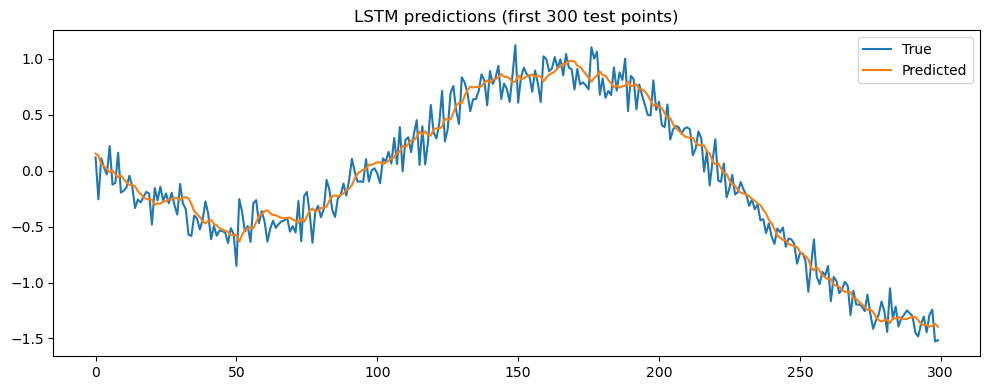

In [67]:
# Plot a subsection
plt.figure(figsize=(10, 4))
n_plot = 300
plt.plot(y_test_inv[:n_plot], label="True")
plt.plot(y_pred_inv[:n_plot], label="Predicted")
plt.title("LSTM predictions (first {} test points)".format(n_plot))
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
# ============================================
# 10. Evaluate
# ============================================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# y_test  → actual values
# y_pred  → predicted values

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))


MAE: 0.03203511962803622
RMSE: 0.03997839954821286
R²: 0.9718218339681717
